# Chapter 3 - Deep Q-learning (Soft Update Version)
### Deep Reinforcement Learning *in Action*
#### This notebook reimplements **Listing 3.7** from `DQN.ipynb` with **Soft Update** (Polyak averaging, tau=0.001) for the target network instead of the original single-network DQN.
#### Environment mode: **`random`**

---
**Soft Update formula:**
$$\theta_{target} \leftarrow \tau\,\theta_{main} + (1-\tau)\,\theta_{target}$$
where $\tau = 0.001$. The target network is updated after **every** training step (continuously), unlike the hard update which copies weights every N steps.

##### Setup

In [1]:
!git clone https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction.git
import os
os.chdir('DeepReinforcementLearningInAction/Chapter 3')
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Cloning into 'DeepReinforcementLearningInAction'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 264 (delta 12), reused 7 (delta 7), pack-reused 244 (from 3)
Receiving objects: 100% (264/264), 3.71 MiB | 15.63 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Using device: cpu


##### Listing 3.7 + Soft Update

In [2]:
import numpy as np
import torch
from Gridworld import Gridworld
from IPython.display import clear_output
import random
from matplotlib import pylab as plt
import copy  # Soft Update Modified: added for deepcopy of target network
from collections import deque

l1 = 64
l2 = 150
l3 = 100
l4 = 4

# Main network (unchanged from Listing 3.7)
model = torch.nn.Sequential(
    torch.nn.Linear(l1, l2),
    torch.nn.ReLU(),
    torch.nn.Linear(l2, l3),
    torch.nn.ReLU(),
    torch.nn.Linear(l3, l4)
).to(device)

# Soft Update Modified: add a target network (copy of main network)
# Original Listing 3.7 had only one network; target network is needed for stable Q-value targets
model2 = copy.deepcopy(model).to(device)
model2.load_state_dict(model.state_dict())

loss_fn = torch.nn.MSELoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

gamma = 0.9
epsilon = 0.3

# Soft Update Modified: define tau for Polyak averaging
# Original Listing 3.7: no target network, no tau
tau = 0.001  # soft-update interpolation coefficient

action_set = {
    0: 'u',
    1: 'd',
    2: 'l',
    3: 'r',
}

In [3]:
from collections import deque
epochs = 5000
losses = []
mem_size = 1000  #A
batch_size = 200  #B
replay = deque(maxlen=mem_size)  #C
max_moves = 50  #D

for i in range(epochs):
    # Soft Update Modified: mode changed to 'random' as required
    game = Gridworld(size=4, mode='random')
    state1_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
    state1 = torch.from_numpy(state1_).float().to(device)
    status = 1
    mov = 0

    while status == 1:
        mov += 1
        qval = model(state1)  #E
        qval_ = qval.cpu().data.numpy()
        if random.random() < epsilon:  #F
            action_ = np.random.randint(0, 4)
        else:
            action_ = np.argmax(qval_)

        action = action_set[action_]
        game.makeMove(action)
        state2_ = game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 100.0
        state2 = torch.from_numpy(state2_).float().to(device)
        reward = game.reward()
        done = True if reward > 0 else False
        exp = (state1, action_, reward, state2, done)  #G
        replay.append(exp)  #H
        state1 = state2

        if len(replay) > batch_size:  #I
            minibatch = random.sample(replay, batch_size)  #J
            state1_batch = torch.cat([s1 for (s1, a, r, s2, d) in minibatch]).to(device)  #K
            action_batch = torch.Tensor([a for (s1, a, r, s2, d) in minibatch]).to(device)
            reward_batch = torch.Tensor([r for (s1, a, r, s2, d) in minibatch]).to(device)
            state2_batch = torch.cat([s2 for (s1, a, r, s2, d) in minibatch]).to(device)
            done_batch = torch.Tensor([d for (s1, a, r, s2, d) in minibatch]).to(device)

            Q1 = model(state1_batch)  #L

            # Soft Update Modified: use target network (model2) to compute Q2
            # Original Listing 3.7: Q2 = model(state2_batch)  (same network as Q1)
            with torch.no_grad():
                Q2 = model2(state2_batch)  #M  -- now evaluated by target network

            Y = reward_batch + gamma * ((1 - done_batch) * torch.max(Q2, dim=1)[0])  #N
            X = Q1.gather(dim=1, index=action_batch.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            print(i, loss.item())
            clear_output(wait=True)
            optimizer.zero_grad()
            loss.backward()
            losses.append(loss.item())
            optimizer.step()

            # Soft Update Modified: apply Polyak soft update to target network after every training step
            # Original Listing 3.7: no target network update at all
            # Compare with hard update (e.g. Double DQN): model2.load_state_dict(model.state_dict()) every sync_freq steps
            # Soft update: theta_target = tau * theta_main + (1 - tau) * theta_target
            for target_param, main_param in zip(model2.parameters(), model.parameters()):
                target_param.data.copy_(
                    tau * main_param.data + (1.0 - tau) * target_param.data
                )

        if reward != -1 or mov > max_moves:  #O
            status = 0
            mov = 0

losses = np.array(losses)

#A Set the total size of the experience replay memory
#B Set the minibatch size
#C Create the memory replay as a deque list
#D Maximum number of moves before game is over
#E Compute Q-values from main network to select action
#F Select action using epsilon-greedy strategy
#G Create experience tuple (state, action, reward, next_state, done)
#H Add experience to experience replay buffer
#I If replay buffer is large enough, start training
#J Randomly sample a minibatch from replay buffer
#K Build separate tensors for each experience component
#L Compute Q-values from main network (with gradients)
#M Compute Q-values from TARGET network (no gradients) -- Soft Update Modified
#N Compute Bellman target Q-values
#O If game is over, reset status and move counter

4999 0.023276420310139656


##### Loss Plot

Text(0.5, 1.0, 'DQN with Soft Update (tau=0.001, mode=random)')

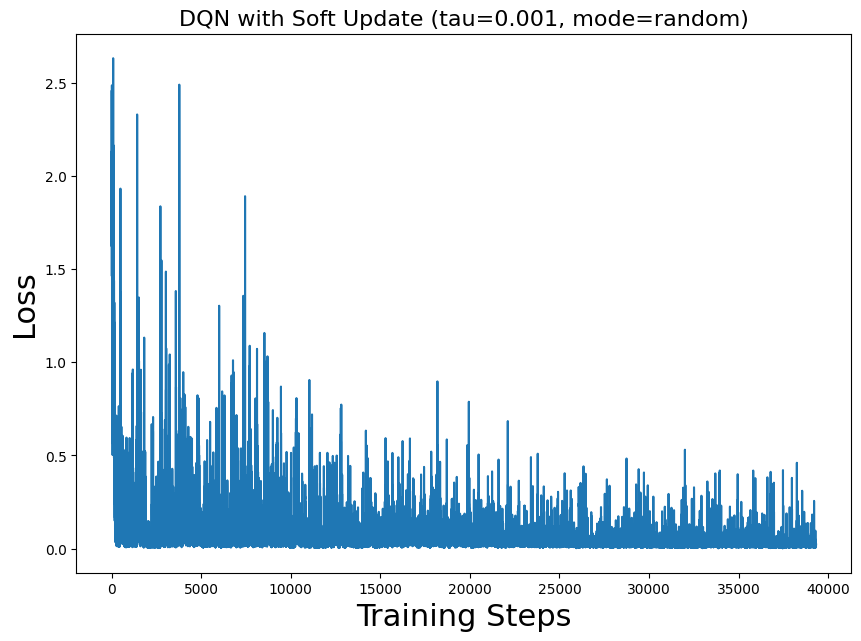

In [4]:
plt.figure(figsize=(10, 7))
plt.plot(losses)
plt.xlabel("Training Steps", fontsize=22)
plt.ylabel("Loss", fontsize=22)
plt.title("DQN with Soft Update (tau=0.001, mode=random)", fontsize=16)

##### Test Model

In [5]:
def test_model(model, mode='static', display=True):
    i = 0
    test_game = Gridworld(mode=mode)
    state_ = test_game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 10.0
    state = torch.from_numpy(state_).float().to(device)
    if display:
        print("Initial State:")
        print(test_game.display())
    status = 1
    while status == 1:
        qval = model(state)
        qval_ = qval.cpu().data.numpy()
        action_ = np.argmax(qval_)
        action = action_set[action_]
        if display:
            print('Move #: %s; Taking action: %s' % (i, action))
        test_game.makeMove(action)
        state_ = test_game.board.render_np().reshape(1, 64) + np.random.rand(1, 64) / 10.0
        state = torch.from_numpy(state_).float().to(device)
        if display:
            print(test_game.display())
        reward = test_game.reward()
        if reward != -1:
            if reward > 0:
                status = 2
                if display:
                    print("Game won! Reward: %s" % (reward,))
            else:
                status = 0
                if display:
                    print("Game LOST. Reward: %s" % (reward,))
        i += 1
        if i > 15:
            if display:
                print("Game lost; too many moves.")
            break
    win = True if status == 2 else False
    return win

In [6]:
max_games = 1000
wins = 0
for i in range(max_games):
    win = test_model(model, mode='random', display=False)
    if win:
        wins += 1
win_perc = float(wins) / float(max_games)
print("Games played: {0}, # of wins: {1}".format(max_games, wins))
print("Win percentage: {}%".format(100.0 * win_perc))

Games played: 1000, # of wins: 910
Win percentage: 91.0%
